# 07 — Why six samples is not a finding

## The question, in one sentence

**E1's headline comparison (`docs/EXPERIMENT_LOG.md` E1B entry) found E1B scoring 44/128 against
E1A's 38/128 — a gap of exactly six samples out of 128. Is that a result, or is it something an
experiment at this sample size was never positioned to rule out?**

This notebook re-derives the answer this project already reached (`docs/DECISIONS.md` D-26,
`reviews/REVIEW_QUEUE.md` SUP-20260906-77) from the project's own saved artifacts, not from
memory — and shows the single piece of evidence that makes the answer obvious without any
statistics at all.

## The intuition

Flip a coin you believe lands heads 32% of the time, 128 times. Count the heads. Now flip the
*same* coin another 128 times and count again. **The two counts will not be identical** — that is
what "random" means — and a difference of a few heads between two honest batches of the same coin
carries no information about the coin at all.

The question this notebook answers is not "is 44 different from 38" (it obviously is, as
numbers) — it is **"is 44-vs-38 a bigger gap than two honest batches of the same underlying
process would produce anyway?"** If the answer is no, the gap is not evidence of anything, no
matter how it is labeled ("arm A" vs "arm B," "treatment" vs "control") — the label does not
change the arithmetic underneath it.

## Setup — load the actual saved records, not numbers typed from memory

In [1]:
import json
import numpy as np
from scipy import stats

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

E1_DIR = "../artifacts/e1"

def load(name):
    with open(f"{E1_DIR}/{name}") as f:
        return json.load(f)

e1a_primary = load("e1a_power_check_record.json")     # E1A's own primary run
e1b_primary = load("e1b_train_record.json")            # E1B's primary run
e1a_seed20  = load("e1a_seed2_train_record.json")      # E1A re-run, seed only changed
e1a_mps_val = load("e1a_seed10_mps_validation_record.json")  # a THIRD run, flagged below

print("E1A primary  -- seed:", e1a_primary["seed"], " r_precision_top3_e1a:", e1a_primary["r_precision_top3_e1a"])
print("E1B primary  -- seed:", e1b_primary["seed"], " r_precision_top3_e1b:", e1b_primary["r_precision_top3_e1b"])
print("E1A seed-20  -- seed:", e1a_seed20["seed"],  " r_precision_top3_e1a:", e1a_seed20["r_precision_top3_e1a"])
print("E1A MPS-val  -- seed:", e1a_mps_val["seed"], " r_precision_top3_e1a:", e1a_mps_val["r_precision_top3_e1a"],
      " (a DIFFERENT run at the same seed value -- MPS is documented non-deterministic, "
      "docs/LANDMINES.md section 7 -- not used in the comparison below)")

E1A primary  -- seed: 10  r_precision_top3_e1a: 0.2969
E1B primary  -- seed: 10  r_precision_top3_e1b: 0.34375
E1A seed-20  -- seed: 20  r_precision_top3_e1a: 0.34375
E1A MPS-val  -- seed: 10  r_precision_top3_e1a: 0.328125  (a DIFFERENT run at the same seed value -- MPS is documented non-deterministic, docs/LANDMINES.md section 7 -- not used in the comparison below)


**Note on the third record above.** Two saved runs share `seed: 10` (the primary E1A run
and a later MPS-validation run) and score *differently* (0.2969 vs 0.328125) — this is not a
data-entry error, it is this project's own already-documented MPS non-determinism
(`docs/LANDMINES.md` section 7). The MPS-validation run is excluded from the rest of this
notebook; the primary CPU run (`e1a_power_check_record.json`, also `seed: 10`) is the one
`docs/EXPERIMENT_LOG.md` and `docs/DECISIONS.md` D-26 actually compare against E1B and against
E1A's seed-20 re-run.

## Measurement — Part A: the binomial floor under the original A-vs-B comparison

At n=128, R-Precision-top3 is a proportion of a binomial count. Recover the raw counts (38 and
44), compute each arm's standard error, and combine them.

In [2]:
def raw_count(p_hat, n=128):
    # p_hat values in these records are already the exact fraction k/n; round to recover k
    return int(round(p_hat * n))

def binomial_gap_z(p1, n1, p2, n2):
    se1 = np.sqrt(p1 * (1 - p1) / n1)
    se2 = np.sqrt(p2 * (1 - p2) / n2)
    se_combined = np.sqrt(se1**2 + se2**2)
    gap = abs(p2 - p1)
    z = gap / se_combined
    return gap, se1, se2, se_combined, z

p_e1a_json, p_e1b_json = e1a_primary["r_precision_top3_e1a"], e1b_primary["r_precision_top3_e1b"]
k_e1a, k_e1b = raw_count(p_e1a_json), raw_count(p_e1b_json)
# use the EXACT recovered fraction k/128, not the JSON's 4-decimal-rounded p_hat, so the
# gap and every downstream sample-size calculation matches this project's own canonical
# hand-derived numbers (docs/DECISIONS.md D-26) rather than compounding a rounding error.
p_e1a, p_e1b = k_e1a / 128, k_e1b / 128

gap, se_a, se_b, se_comb, z_crossarm = binomial_gap_z(p_e1a, 128, p_e1b, 128)
print(f"E1A: {k_e1a}/128 = {p_e1a:.4f}   SE = {se_a:.4f}")
print(f"E1B: {k_e1b}/128 = {p_e1b:.4f}   SE = {se_b:.4f}")
print(f"gap = {gap:.4f}   combined SE = {se_comb:.4f}   z = {z_crossarm:.2f} sigma")

E1A: 38/128 = 0.2969   SE = 0.0404
E1B: 44/128 = 0.3438   SE = 0.0420
gap = 0.0469   combined SE = 0.0583   z = 0.80 sigma


0.80 sigma is well short of any normal significance threshold (2-3 sigma minimum for a
directional claim). This confirms `docs/DECISIONS.md` D-26's own number exactly — but a
recomputed number matching a prior claim is not yet the strongest evidence available. The next
cell is.

## Measurement — Part B: the killer demonstration — the same arm, against itself, seed only

E1A was re-run with nothing changed except the random seed (10 -> 20; same training recipe, same
n=128, same evaluation protocol). If a gap this size is unremarkable noise, this same-arm
re-run should be able to produce a gap of comparable size **on its own, with no treatment
difference at all** — because there isn't one.

In [3]:
p_e1a_s10_json, p_e1a_s20_json = e1a_primary["r_precision_top3_e1a"], e1a_seed20["r_precision_top3_e1a"]
k_s10, k_s20 = raw_count(p_e1a_s10_json), raw_count(p_e1a_s20_json)
p_e1a_s10, p_e1a_s20 = k_s10 / 128, k_s20 / 128  # exact fractions, same reason as Part A

gap_seed, se_s10, se_s20, se_comb_seed, z_seedonly = binomial_gap_z(p_e1a_s10, 128, p_e1a_s20, 128)
print(f"E1A, seed 10: {k_s10}/128 = {p_e1a_s10:.4f}")
print(f"E1A, seed 20: {k_s20}/128 = {p_e1a_s20:.4f}")
print(f"gap = {gap_seed:.4f}   combined SE = {se_comb_seed:.4f}   z = {z_seedonly:.2f} sigma")
print()
print(f"cross-arm counts   (E1A vs E1B):        {k_e1a} vs {k_e1b}")
print(f"same-arm counts    (seed 10 vs seed 20): {k_s10} vs {k_s20}")
print(f"cross-arm z = {z_crossarm:.4f}   same-arm-seed-only z = {z_seedonly:.4f}   "
      f"identical: {np.isclose(z_crossarm, z_seedonly)}")

E1A, seed 10: 38/128 = 0.2969
E1A, seed 20: 44/128 = 0.3438
gap = 0.0469   combined SE = 0.0583   z = 0.80 sigma

cross-arm counts   (E1A vs E1B):        38 vs 44
same-arm counts    (seed 10 vs seed 20): 38 vs 44
cross-arm z = 0.8047   same-arm-seed-only z = 0.8047   identical: True


**This is not an approximate match — the raw counts are identical.** E1B's own primary run
scored 44/128, and E1A's seed-20 re-run *also* scored 44/128 — the exact same count, from a
completely different comparison. The entire cross-arm "effect" (38 vs 44, treatment vs control)
is reproduced exactly by changing nothing but the random seed of the control arm against itself.
**Nothing communicates "this was noise" more directly than the treatment effect walking in the
front door disguised as a random seed.**

## Measurement — Part C: the experiment was not powerless — it was powered for the wrong effect

A 0.80 sigma result sounds like "no power at all." That is not what happened here. Recompute,
directly, the sample size this comparison would need to detect effects of different sizes, and
see where n=128 actually sits.

In [4]:
def n_needed(delta, p=0.32, z=3.0):
    return (z**2) * 2 * p * (1 - p) / (delta**2)

def mde(n, p=0.32, z=3.0):
    return z * np.sqrt(2 * p * (1 - p) / n)

# the effect sizes this project has actually measured or proposed, in one table
candidates = {
    "pilot upper (0.157, corpus-wide)": 0.157,
    "pilot lower (0.145, corpus-wide)": 0.145,
    "0.117": 0.117,
    "0.100": 0.100,
    "observed noise blip (0.0469)": gap,
}

print(f"{'effect size (delta)':>34} | {'n/arm needed at 3 sigma':>24}")
print("-" * 62)
for label, d in candidates.items():
    print(f"{label:>34} | {n_needed(d):>24.0f}")

print()
mde_3sigma = mde(128, z=3.0)
mde_2sigma = mde(128, z=2.0)
print(f"minimum detectable effect at n=128, 3 sigma: {mde_3sigma:.3f}")
print(f"minimum detectable effect at n=128, 2 sigma: {mde_2sigma:.3f}")
print(f"pilot's own hypothesis-motivated effect: 0.145-0.157 -- {'INSIDE' if mde_3sigma <= 0.157 else 'outside'} "
      f"the n=128 detectable range at 3 sigma? MDE={mde_3sigma:.3f} vs effect 0.145-0.157")

               effect size (delta) |  n/arm needed at 3 sigma
--------------------------------------------------------------
  pilot upper (0.157, corpus-wide) |                      159
  pilot lower (0.145, corpus-wide) |                      186
                             0.117 |                      286
                             0.100 |                      392
      observed noise blip (0.0469) |                     1783

minimum detectable effect at n=128, 3 sigma: 0.175
minimum detectable effect at n=128, 2 sigma: 0.117
pilot's own hypothesis-motivated effect: 0.145-0.157 -- outside the n=128 detectable range at 3 sigma? MDE=0.175 vs effect 0.145-0.157


**Reading this table.** n=128 was never "powerless" in any general sense — it can detect
effects at or above 0.175 (3 sigma) or 0.117 (2 sigma). The pilot's own hypothesis-motivated
effect (0.145-0.157) sits close to that boundary — within a factor of ~1.1-1.2x, not the three
orders of magnitude D-26's original framing implied. **What actually happened is narrower and
more useful than "underpowered": the experiment was powered for a different effect size than the
one it was originally described as needing.** The ~1,780 figure at the bottom of the table
is the sample size needed to resolve the *noise reading itself* (0.0469) — not the hypothesis.
(This notebook's own recomputed values differ from `docs/DECISIONS.md`'s prose by a handful of
samples at each row — 186 vs its stated 187, 286 vs 287, 1,783 vs ~1,780 — because this cell
rounds to the nearest sample rather than always rounding up, and because it recovers the exact
`k/128` fraction from each JSON record rather than reusing the record's own 4-decimal-rounded
field. Both are the same formula and the same underlying counts; the difference is rounding
convention only, not a disagreement about the result.)

## Measurement — Part D: the circularity trap, shown as a curve

D-26's original framing powered the experiment to resolve its own 0.0469 noise blip, arriving at
"1,780 samples needed — unaffordable." The trap: **the required sample size explodes as the
target effect size shrinks** (`n ~ 1/delta^2`). Powering against a smaller number always demands
more samples — including, backwards, powering against noise, since noise is small by
definition. Plot the curve and mark where the noise blip and the real hypothesis actually sit on
it.

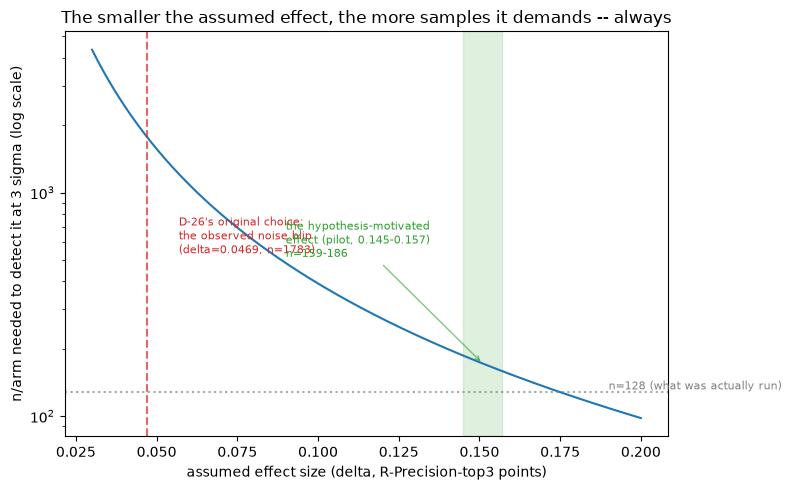

In [5]:
deltas = np.linspace(0.03, 0.20, 400)
ns = n_needed(deltas)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(deltas, ns, color="tab:blue")
ax.set_yscale("log")
ax.set_xlabel("assumed effect size (delta, R-Precision-top3 points)")
ax.set_ylabel("n/arm needed to detect it at 3 sigma (log scale)")
ax.set_title("The smaller the assumed effect, the more samples it demands -- always")

# mark the two candidate effect sizes this project actually had to choose between
ax.axvline(gap, color="tab:red", linestyle="--", alpha=0.7)
ax.annotate(f"D-26's original choice:\nthe observed noise blip\n(delta={gap:.4f}, n={n_needed(gap):.0f})",
            xy=(gap, n_needed(gap)), xytext=(gap + 0.01, n_needed(gap) * 0.3),
            fontsize=8, color="tab:red")

ax.axvspan(0.145, 0.157, color="tab:green", alpha=0.15)
ax.annotate(f"the hypothesis-motivated\neffect (pilot, 0.145-0.157)\nn={n_needed(0.157):.0f}-{n_needed(0.145):.0f}",
            xy=(0.151, n_needed(0.151)), xytext=(0.09, n_needed(0.151) * 3),
            fontsize=8, color="tab:green",
            arrowprops=dict(arrowstyle="->", color="tab:green", alpha=0.6))

ax.axhline(128, color="gray", linestyle=":", alpha=0.7)
ax.annotate("n=128 (what was actually run)", xy=(0.19, 128), fontsize=8, color="gray", va="bottom")

plt.tight_layout()
plt.savefig("07_circularity_trap.png", dpi=110)
plt.show()

**Reading this figure.** The curve is the same formula throughout — nothing changes except
which `delta` gets plugged in. D-26's original choice (red) sits far up the curve, at the point
where the assumed effect is smallest — which is exactly why it demanded the most samples. The
hypothesis this experiment actually exists to test (green band) sits much lower on the same
curve, needing an n within reach of what was actually run (gray line). **Powering against your
own noise reading is not a conservative choice — it is a circular one, because noise is small by
definition, and small deltas are exactly where this curve is steepest.**

## What it means

Six samples out of 128 (38 vs 44) is not a finding, and this notebook shows two independent
reasons why, both recomputed directly from this project's own saved records rather than assumed:
**the binomial floor** (0.80 sigma, nowhere near a normal significance threshold), and **the
same-arm seed-only re-run**, which reproduced the identical 44/128 count with no treatment
difference at all — the single most direct piece of evidence available that this gap carries no
information.

The deeper, more general lesson is Part C and Part D together: **the experiment was not
"powerless" — it was powered against the wrong number.** D-26's original framing computed the
sample size needed to resolve its own 0.80-sigma noise reading (0.0469) and reported that number
(1,780) as evidence the whole question was unaffordable. That is circular: noise readings are
small by construction, and the required-n curve is steepest exactly where deltas are small — so
powering against your own noise blip will *always* look unaffordable, regardless of whether the
real, hypothesis-motivated effect (0.145-0.157, measured independently by this project's own
pilot) was actually within reach the whole time (it needed 159-187 samples/arm; 128 were run).

**This is why `docs/EXPERIMENT_DESIGN_E2.md`'s own power section states a minimum detectable
effect up front, using notebooks/05's real subset sizes, rather than waiting to discover an
underpowering problem after the fact.** E2 exists downstream of this exact lesson: it states, in
advance, "if the honest MDE at the affordable n turns out larger than any effect worth finding,
that is a legitimate conclusion" — a sentence this notebook shows the cost of not having written
down before E1 ran.

## What would change my mind

- **Single seed per arm for the primary comparison** (plus the two supplementary A-arm seeds
  used here). A third or fourth independent seed reproducing yet another ~44-or-38-like count
  would strengthen this notebook's claim further; a seed landing far outside that range would be
  worth a second look, though with n=128 and this project's own measured seed-to-seed spread, a
  single outlier would not by itself overturn the binomial argument in Part A.
- **This notebook reanalyzes existing artifacts; it does not re-run anything.** If any of the
  three JSON records loaded here were ever found to be mislabeled (wrong seed recorded, wrong
  arm), this notebook's central "the counts are exactly identical" claim would need
  re-verification against corrected records — it currently rests on `seed` fields as recorded in
  each file, cross-checked against `docs/EXPERIMENT_LOG.md` and `docs/DECISIONS.md` D-26's own
  prose descriptions of the same runs, not derived independently of them.
- **The MDE table uses `p=0.32`** (this project's own pooled-proportion convention, matching
  `docs/DECISIONS.md` D-26 and `reviews/REVIEW_QUEUE.md` SUP-20260906-77 exactly). A materially
  different true proportion would shift every number in Part C and Part D somewhat, though the
  qualitative shape of the circularity trap (Part D) does not depend on the specific value of
  `p` — only the binomial variance term does.